### **Práctica 3**

Estudiantes:

Luisa María Martínez Muelas

Carolina Taborda Vargas

### **Marco teórico**

**Señales estacionarias y no estacionarias**

1. Cuando una señal es estacionaria es porque tiene un ruido aleatorio con media y varianza constantes.

2. Cuando hay diferentes cambios de la señal con respecto al tiempo

**Hipótesis para comprobar diferencias entre señales**

**1. Hipótesis nula (H0):** La señal es estacionaria

**2.Hipótesis alternativa (H1):** La señal no es estacionaria


Las pruebas estadísticas de dividen en prarámetricas y no paramétricas, dependiendo de si hacen superposiciones sobre la distribución de datos.

**1. Paramétricas:** Cuando los datos siguen una distribución normal

    Homocedasticidad: varianzas similares entre los grupos

    Independencia: Observaciones independientes

    Ejemplo: prueba t de Student (Comparación de medias)

**2. No paramétricas:** Cuando los datos NO siguen una distribución normal o son ordinales

    Ejemplo: Prueba U de Mann-Whitney

#### **Implementación de funciones**



In [2]:
#Importación de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io
from scipy.io import loadmat

In [3]:
#Análisis exploratorio de datos
import scipy.io
data=scipy.io.loadmat('signals.mat')

# Ver los nombres de las variables disponibles
print("Variables en el archivo:", data.keys())

Variables en el archivo: dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])


#### **Construcción de la función RMS**

In [4]:
#CONSTRUCCIÓN DE LA FUNCIÓN RMS
def calcular_rms(signal):
    signal = np.array(signal)
    rms = np.sqrt(np.mean(signal**2))
    return rms

In [5]:
# Extracción de las señales para ver su tamaño 
as_recording = data['ECG_asRecording']
filtered = data['ECG_filtered']

print(f"Tamaño de señales originales: {as_recording.shape}")
print(f"Tamaño de señales filtradas: {filtered.shape}")

Tamaño de señales originales: (1, 30720)
Tamaño de señales filtradas: (1, 30720)


### **ANÁLISIS ESTADISTICO DE ECG**

**1. Tiempo de duración de la señal**

In [6]:
data = loadmat('signals.mat')
#DATOS
recording = data['ECG_asRecording'].squeeze()
filtered = data['ECG_filtered'].squeeze()

#FRECUENCIA DE MUESTREO
fs = 1024  # Hz

N = len(recording)
duracion = N/fs

print("Duración de la señal:", duracion, "segundos")


Duración de la señal: 30.0 segundos


In [7]:
recording.squeeze()


array([3904.31689453, 3939.203125  , 3976.00683594, ..., 4366.41064453,
       4365.31103516, 4370.91796875])

#### **Vector de tiempo**

In [8]:
#Vector de tiempo
t=np.arange(0,N)/fs
print(t)

[0.00000000e+00 9.76562500e-04 1.95312500e-03 ... 2.99970703e+01
 2.99980469e+01 2.99990234e+01]


#### **Gráficas**

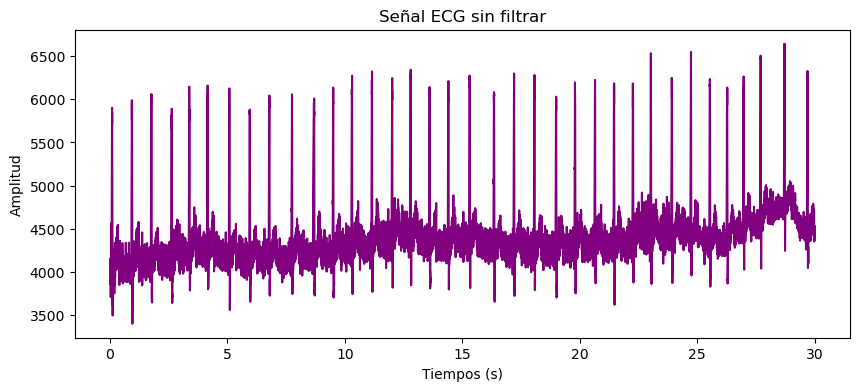

In [9]:
#Señal sin filtrar
plt.figure(figsize=(10,4))
plt.plot(t, recording, color="purple")
plt.title("Señal ECG sin filtrar")
plt.xlabel("Tiempos (s)")
plt.ylabel("Amplitud")
plt.show()


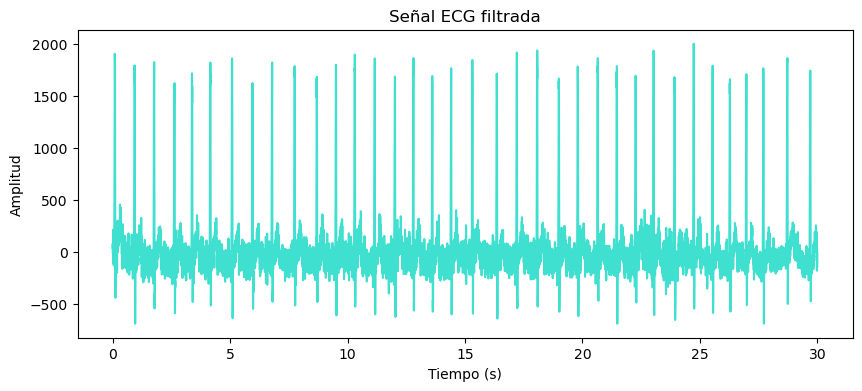

In [10]:
#Señal filtrada
plt.figure(figsize=(10,4))
plt.plot(t, filtered, color="turquoise")
plt.title("Señal ECG filtrada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.show()

Al comparar ambas señales se observan algunas  diferencias principales:

**Eliminación del offset DC:** La señal sin filtrar presenta una línea 
base elevada de aproximadamente 4200-4500 unidades de amplitud, 
mientras que la señal filtrada se encuentra centrada alrededor de 0. 
Esto indica que el filtro eliminó la componente de corriente continua 
(DC) presente en el registro original.

**Escala de amplitud:** Los picos R (pico más alto) de la señal sin filtrar alcanzan 
valores de amplitud de hasta 6500, mientras que en la señal filtrada los mismos 
picos se ubican alrededor de 2000. Esta diferencia es consistente 
con la eliminación del offset DC (4200).

**Ruido de alta frecuencia:** Aunque la señal filtrada presenta una 
reducción del ruido respecto a la original, aún se observan 
oscilaciones de alta frecuencia superpuestas, lo que sugiere que 
el filtro aplicado fue principalmente un filtro pasa-altas o 
pasa-banda que eliminó las componentes DC y de muy baja frecuencia, 
pero no actuó fuertemente sobre el ruido de alta frecuencia.

Para una señal ECG, las frecuencias de interés clínico se encuentran 
entre 0.05 Hz y 150 Hz. El complejo QRS concentra su energía entre 
5 y 40 Hz. El filtro aplicado parece ser un pasa-banda que eliminó 
el offset DC (componentes por debajo de 0.05 Hz) preservando las 
frecuencias cardíacas de interés, aunque con ruido residual aún presente.
Descartamos que sea un filtro pasa altas ya que si tuviéramos la presencia de este filtro, 
eso significaría que tendríamos ruidos de mucha más alta frecuencia, mientras que el pasa bandas
nos permite seleccionar las bandas de interés de nuestra señal cardiaca.

#### **Selección de un ciclo cardiaco**

Media: 4217.113559961319
RMS: 4225.231244389823
Varianza: 68532.2909583424
STD: 261.7867280026671


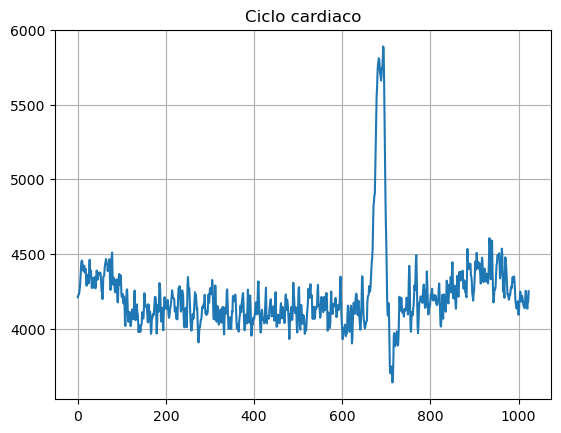

In [11]:
#Ciclo señal cardiaca
ciclo = recording[2000:3024]   #Se le multiplica la duración del ciclo cardiaco (0.8) aprox 1 y se le suma al valor incial de la frecuencia

media = np.mean(ciclo)
rms = calcular_rms(ciclo)
varianza = np.var(ciclo)
std = np.std(ciclo)

print("Media:", media)
print("RMS:", rms)
print("Varianza:", varianza)
print("STD:", std)

plt.plot(ciclo)
plt.title("Ciclo cardiaco")
plt.grid()
plt.show()

#### **Cálculo de métricas para ciclo cardiaco**

Media: -6.437055592946869
RMS: 255.90806847942466
Varianza: 65447.503828163215
STD: 255.82709752519028


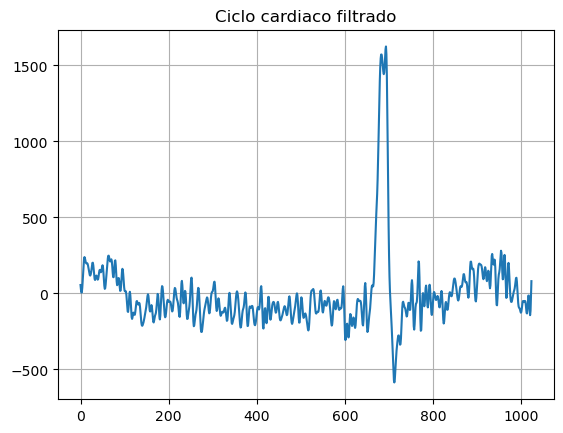

In [12]:
#Señal filtrada
ciclo_f = filtered[2000:3024]

media_f = np.mean(ciclo_f)
rms_f = calcular_rms(ciclo_f)
var_f = np.var(ciclo_f)
std_f = np.std(ciclo_f)

print("Media:", media_f)
print("RMS:", rms_f)
print("Varianza:", var_f)
print("STD:", std_f)

plt.plot(ciclo_f)
plt.title("Ciclo cardiaco filtrado")
plt.grid()
plt.show()


Al comparar los estadísticos del ciclo sin filtrar y el ciclo filtrado, 
se observan diferencias notables:

- La media del ciclo sin filtrar (4217) es considerablemente mayor que 
  la del ciclo filtrado (-6.4), lo que indica que la señal sin filtrar 
  presenta una componente de corriente continua (DC offset) que el filtro 
  eliminó correctamente.
  
- El RMS sin filtrar (4225) es mucho mayor que el filtrado (255.9), 
  consistente con la eliminación del offset DC.
  
- La varianza y desviación estándar son similares en ambas señales 
  (68532 vs 65447), lo que sugiere que la variabilidad intrínseca del 
  ciclo cardíaco se preservó tras el filtrado.


#### **Ciclos de la señal filtrada**

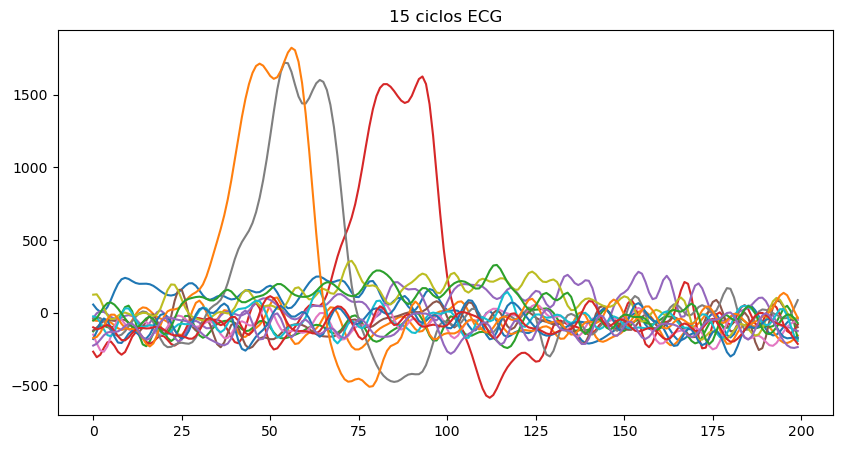

Ciclo | Media        | Varianza
----------------------------------------
   1  |      22.8647 |   17112.6538
   2  |     -86.3195 |    6038.9157
   3  |     -96.1099 |    3916.7662
   4  |      79.9015 |  270196.5784
   5  |      54.9763 |   10573.5198
   6  |     -69.8934 |    5902.7979
   7  |     -86.5829 |    4908.7491
   8  |     118.4129 |  265086.6453
   9  |      78.3048 |   14272.6833
  10  |     -51.1989 |    4832.4243
  11  |     -75.5130 |    7504.1603
  12  |     133.8063 |  299402.8970
  13  |      60.0826 |   13818.9037
  14  |     -83.9514 |    4217.6261
  15  |    -113.8549 |    4326.7641


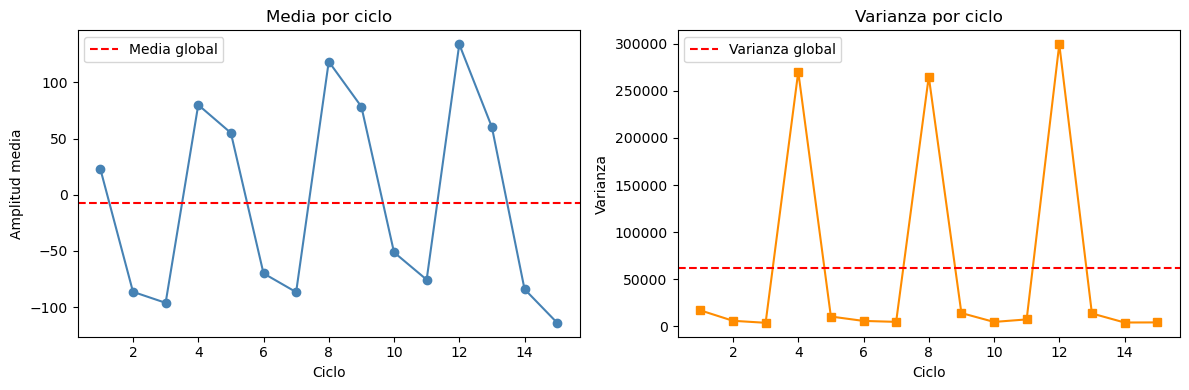

In [13]:
#15 ciclos
ciclos = []
inicio = 2000
tam = 200 #aproximamos el ciclo que es 0.8

for i in range(15):
    ciclos.append(filtered[inicio+i*tam : inicio+(i+1)*tam])

medias = []
varianzas = []

for c in ciclos:
    medias.append(np.mean(c))
    varianzas.append(np.var(c))

plt.figure(figsize=(10,5))

for c in ciclos:
    plt.plot(c)

plt.title("15 ciclos ECG")
plt.show()

# 1. Tabla de estadísticas por ciclo
print("Ciclo | Media        | Varianza")
print("-" * 40)
for i, (m, v) in enumerate(zip(medias, varianzas)):
    print(f"  {i+1:2d}  | {m:12.4f} | {v:12.4f}")

# 2. Graficas de  medias y varianzas por ciclo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, 16), medias, marker='o', color='steelblue')
axes[0].axhline(np.mean(medias), color='red', linestyle='--', label='Media global')
axes[0].set_title("Media por ciclo")
axes[0].set_xlabel("Ciclo")
axes[0].set_ylabel("Amplitud media")
axes[0].legend()

axes[1].plot(range(1, 16), varianzas, marker='s', color='darkorange')
axes[1].axhline(np.mean(varianzas), color='red', linestyle='--', label='Varianza global')
axes[1].set_title("Varianza por ciclo")
axes[1].set_xlabel("Ciclo")
axes[1].set_ylabel("Varianza")
axes[1].legend()

plt.tight_layout()
plt.show()

Las gráficas de media y varianza por ciclo muestran que la señal ECG 
presenta variaciones entre ciclos. La media oscila entre valores positivos 
y negativos, y la varianza presenta picos elevados en algunos ciclos 
correspondientes al complejo QRS (pico R). 

Para que una señal sea estacionaria en sentido estricto, su media y 
varianza deben permanecer constantes en el tiempo. Dado que ambas 
fluctúan entre los 15 ciclos analizados, se podría sugerir 
que la señal no es estacionaria.

#### **Comparaciones entre dos ciclos**

En primera instancia, se asume que los ciclos son independientes ya que corresponden a segmentos diferentes de la señal

In [14]:
#Primera elección de los ciclos a comparar

ciclo1 = ciclos[0]
ciclo2 = ciclos[4]

#Verificación de supuestos con Shapiro-Wilk (NORMALIDAD)

from scipy.stats import shapiro

stat1, p1 = shapiro(ciclo1)
stat2, p2 = shapiro(ciclo2)

print("Normalidad ciclo 1: p =", p1)
print("Normalidad ciclo 2: p =", p2)

Normalidad ciclo 1: p = 9.91414481177344e-07
Normalidad ciclo 2: p = 0.02280138060450554


Al evaluar la normalidad de los ciclos mediante la prueba de Shapiro-Wilk, se obtuvieron valores p menores a 0.05 en ambos casos, lo que indica que los datos no siguen una distribución normal.

In [15]:
# HOMOCEDASTICIDAD
from scipy.stats import levene

stat_levene, p_levene = levene(ciclo1, ciclo2)

print("Levene p =", p_levene)

Levene p = 1.8519982977271893e-06


Al realizar la prueba de Levene para evaluar la homocedasticidad entre los ciclos cardíacos, se obtuvo un valor p menor a 0.05, lo que indica que existen diferencias significativas entre las varianzas de los ciclos. Por lo tanto, no se cumple el supuesto de homocedasticidad.

Por otro lado, como no se cumplen los supuestos entonces se realiza un análisis no paramétrico por medio de  la prueba U de Mann-Whitney

In [16]:
#PRUEBA NO PARAMÉTRICA: U DE MANN-WHITNEY

from scipy.stats import mannwhitneyu

stat_u, p_u = mannwhitneyu(ciclo1, ciclo2)

print("U =", stat_u)
print("p =", p_u)

U = 17171.0
p = 0.014425214085053569


Dado que ninguno de los supuestos se cumplió (ni normalidad ni homocedasticidad), se aplicó la prueba U de Mann-Whitney, la cual no requiere distribución normal ni igualdad de varianzas. El valor p = 0.0144 < 0.05 indica que existe una diferencia estadísticamente significativa entre las distribuciones de los ciclos. Esto sugiere que las propiedades estadísticas de la señal cambian entre segmentos temporales distantes, lo cual es un indicador de no estacionariedad.

#### **Segunda comparación entre ciclos**

De la misma manera, se asume independencia entre los ciclos debido a que corresponden a segmentos diferentes de la señal

In [17]:
#Segunda elección de ciclos a comparar 

ciclo3 = ciclos[1]
ciclo4 = ciclos[6]

#Verificación de supuestos con Shapiro-Wilk (NORMALIDAD)

from scipy.stats import shapiro

stat1, p1 = shapiro(ciclo3)
stat2, p2 = shapiro(ciclo4)

print("Normalidad ciclo 1: p =", p1)
print("Normalidad ciclo 2: p =", p2)

Normalidad ciclo 1: p = 0.17364215850830078
Normalidad ciclo 2: p = 0.15213747322559357


Luego de realizar la prueba de Shapiro-Wilk para evaluar la normalidad, se obtuvieron valores p mayores a 0.05 lo que indica que los datos siguen una distribución normal. 

In [18]:
# HOMOCEDASTICIDAD
from scipy.stats import levene

stat_levene, p_levene = levene(ciclo3, ciclo4)

print("Levene p =", p_levene)

Levene p = 0.13828806479300676


Al realizar la prueba de Levene para evaluar la homocedasticidad entre los ciclos cardíacos, se obtuvo un valor p mayor a 0.05, lo que indica que hay una varianza igual entre los ciclos y por lo tanto, se presenta homocedasticidad. 

Luego de verificar que se cumplen los supuestos, se procede a realizar la prueba t-test para identificar si existe o no, una diferencia entre las medias de los ciclos tomados.

In [19]:
#PRUEBA T-TEST
from scipy.stats import ttest_ind

t_stat, p_t = ttest_ind(ciclo3, ciclo4, equal_var=True)

print("t =", t_stat)
print("p =", p_t) 

t = 0.03551295066300682
p = 0.9716885238656062


Al cumplirse los supuestos de normalidad (Shapiro-Wilk, p > 0.05 en ambos ciclos) y homocedasticidad (Levene, p = 0.1383 > 0.05), se aplicó la prueba t de Student para muestras independientes con varianzas iguales. El resultado p = 0.9717 >> 0.05 indica que no existe diferencia significativa entre las medias de los ciclos, lo que sugiere estacionariedad en esa región de la señal.


#### **Prueba de Dickey-Fuller**

La prueba de Dickey-Fuller aumentada (ADF) se aplicará con el fin de evaluar la estacionariedad de la señal en su totalidad. A diferencia de las pruebas estadísticas realizadas previamente entre segmentos (t de Student y Mann-Whitney), que evidenciaron comportamientos distintos dependiendo de la región analizada, la prueba ADF nos permitirá determinar si la señal presenta una raíz unitaria, lo cual indicaría no estacionariedad global.

En los análisis por segmentos, se observaron resultados inconsistentes. Mientras que en una comparación se encontraron diferencias estadísticamente significativas entre ciclos (p = 0.0144), en otra no se evidenciaron diferencias (p = 0.9717). Por lo tanto, la aplicación de la prueba ADF permite confirmar si estos cambios corresponden a una tendencia global no estacionaria o a variaciones locales dentro de una señal estacionaria.

Para realizar la prueba ADF, debemos verificar que nuestros datos sean un arreglo unidimensional. Asimismo, trabajaremos con la sección en la que la señal de ECG se encuentre filtrada


In [20]:
#Anlizamos la dimensión de nuestro set de datos para aplicar la prueba

print(data['ECG_filtered'].shape)

(1, 30720)


Las hipótesis que debe cumplir la prueba de Dickey-Fuller son las siguientes:

**1. Hipótesis nula (H0):** La serie tiene una raíz unitaria -- La señal no es estacionaria

**2. Hipótesis alternativa (H1):** La serie no tiene una raíz unitaria -- La señal es estacionaria

Las hipótesis se analizarán con los valores de p y con el valor crítico con el estadístico ADF. Para este caso, se tiene en cuenta que:

- p < 0.05 -- se rechaza H₀ --  estacionaria

- p > 0.05 -- no se rechaza H₀ -- no estacionaria

- Si ADF < valor crítico -- se rechaza H₀
- Si ADF > valor crítico -- no se rechaza



In [21]:
from statsmodels.tsa.stattools import adfuller

#Como en la celda anterior vimos que la señal no cumple con el requisito para hacer la prueba, entonces usamos la función .flatten() para aplanar el set de datos y poder realizar la prueba

señal_1d = data['ECG_filtered'].flatten()

resultado_adf = adfuller(señal_1d)

print("Estadístico ADF:", resultado_adf[0])
print("p-valor:", resultado_adf[1])
print("Número de lags usados:", resultado_adf[2])
print("Número de observaciones:", resultado_adf[3])
print("Valores críticos:")
for clave, valor in resultado_adf[4].items():
    print(f"   {clave}: {valor}")

Estadístico ADF: -24.498421904256478
p-valor: 0.0
Número de lags usados: 19
Número de observaciones: 30700
Valores críticos:
   1%: -3.4305630243276717
   5%: -2.861634151073544
   10%: -2.5668201137295887


Bajo la hipótesis nula de que la señal presenta una raíz unitaria (es decir, no es estacionaria), se obtuvo un p-valor de 0.0, menor al nivel de significancia de 0.05, además de un estadístico ADF (-24.5) considerablemente menor que los valores críticos de la prueba. Por lo tanto, se rechaza la hipótesis nula, concluyendo que la señal es estacionaria.

Adicionalmente, aunque en el análisis por segmentos se observaron diferencias estadísticas en algunas comparaciones y similitudes en otras, estos resultados reflejan variaciones locales en la señal. Sin embargo, la prueba de Dickey-Fuller, al evaluar la señal completa, confirma que dichas variaciones no afectan su comportamiento global, el cual puede considerarse estacionario.

#### **Conclusiones**

1. La señal ECG registrada tiene una duración de 30 segundos con una 
   frecuencia de muestreo de 1024 Hz, lo que proporciona 30.720 muestras 
   para el análisis.

2. El filtrado eliminó efectivamente el ruido de alta frecuencia y el 
   offset DC de la señal, preservando las características morfológicas 
   del ECG. Esto se evidenció al comparar los estadísticos del ciclo 
   sin filtrar (media 4217) y filtrado (media -6.4).

3. El análisis estadístico por comparación de ciclos mostró resultados 
   mixtos: la primera comparación (ciclos[0] vs ciclos[4]) evidenció 
   diferencias significativas (Mann-Whitney, p=0.0144), mientras que la 
   segunda (ciclos[1] vs ciclos[6]) no mostró diferencias (t-test, 
   p=0.9717). Esto sugiere variabilidad local en la señal.

4. La prueba de Dickey-Fuller Aumentada aplicada sobre la señal completa 
   arrojó un estadístico ADF de -24.498 y p = 0, rechazando la hipótesis 
   nula de raíz unitaria. Esto indica que la señal ECG es globalmente 
   estacionaria, aunque presenta variaciones locales entre algunos 
   segmentos.

5. La combinación de pruebas paramétricas y no paramétricas, junto con 
   la prueba ADF, permite concluir que la señal presenta estacionariedad 
   global con variabilidad local, comportamiento típico de señales 
   fisiológicas como el ECG.

#### **Referencias**

1. Frecuencias cardiacas

Becerra-Luna, B., Dávila-García, R., Salgado-Rodríguez, P., Martínez-Memije, R., & Infante-Vázquez, O. (2012). Monitor de señales de electrocardiografía y frecuencia cardiaca mediante un teléfono móvil con el protocolo de comunicación Bluetooth. Archivos de cardiologia de Mexico, 82(3), 197–203. https://doi.org/10.1016/j.acmx.2012.04.005

2. Uso del código con statsmodels en python

Statsmodels Developers. (2024). statsmodels.tsa.stattools.adfuller. https://www.statsmodels.org/

3. Pruebas paramétricas y no paramétricas en pyhton

Nonparametric_Statistical_Significance_Tests. (s/f). Github.io. Recuperado de https://jmyao17.github.io/Statistics/Nonparametric_Statistical_Significance_Tests.html

4. Implementación de la prueba de Dickey-Fuller

Augmented dickey-fuller (ADF). (2025, junio 17). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/augmented-dickey-fuller-adf/





